In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Load the dataset
df = pd.read_csv('segmented_customer_data.csv')

# 2. As already  Defined in segmentation.ipynb: Churn (1) based on Cluster 2 (Churned / At-Risk) 
# or if their recency is exceptionally high (top 30%)
recency_threshold = df['Recency'].quantile(0.70)
df['Churn'] = np.where((df['Cluster'] == 2) | (df['Recency'] > recency_threshold), 1, 0)

# 3. Print the class balance to see how it looks now
print("--- Dataset Snapshot ---")
print(df.head())
print("\n--- Churn Class Distribution ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- Dataset Snapshot ---
   CustomerID  Recency  Frequency  Monetary  Cluster            Segment  Churn
0       12346      326          1  77183.60        0   Regular Shoppers      1
1       12347        2          7   4310.00        1      VIP Customers      0
2       12348       75          4   1797.24        0   Regular Shoppers      0
3       12349       19          1   1757.55        0   Regular Shoppers      0
4       12350      310          1    334.40        2  Churned / At-Risk      1

--- Churn Class Distribution ---
Churn
0    53.8497
1    46.1503
Name: proportion, dtype: float64


In [18]:
# 1. Separate features (X) and target variable (y)
# We drop leakage columns and identifiers
X = df.drop(columns=['CustomerID', 'Cluster', 'Segment', 'Churn'], errors='ignore')
y = df['Churn']

# 2. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
rf_model.fit(X_train, y_train)

# 4. Generate predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Model training complete! Ready to evaluate performance.")

Model training complete! Ready to evaluate performance.


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       467
           1       0.99      0.99      0.99       401

    accuracy                           0.99       868
   macro avg       0.99      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



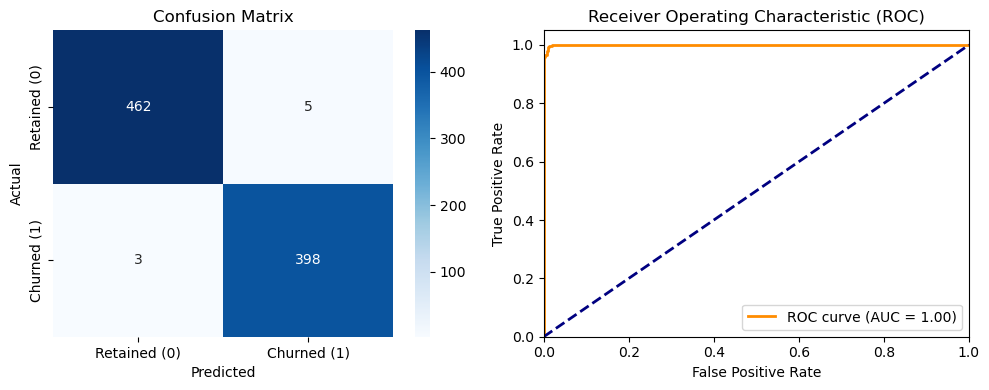

In [19]:
# 1. Print the Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Compute and Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 3. Compute and Plot ROC-AUC Curve
auc_score = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

C:\Users\monih\AppData\Local\Temp\ipykernel_23252\3763000917.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


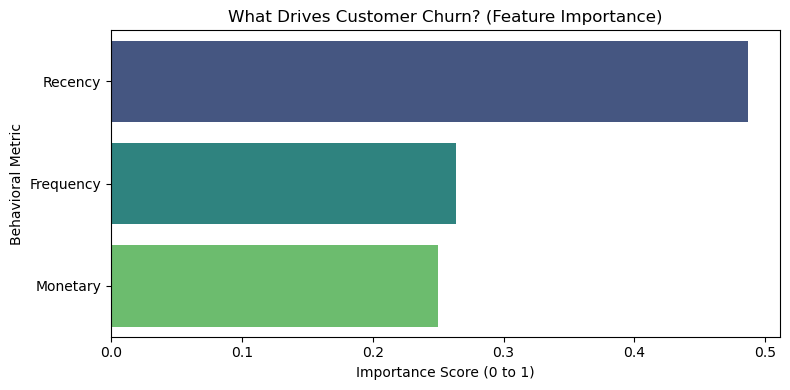

--- Feature Importance Breakdown ---
  Feature  Importance
  Recency    0.486857
Frequency    0.263580
 Monetary    0.249563


In [20]:
# 1. Extract mathematical feature importances from our trained model
importances = rf_model.feature_importances_
features = X.columns

# 2. Create a clean DataFrame to sort them
feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Create a clean horizontal bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('What Drives Customer Churn? (Feature Importance)')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Behavioral Metric')
plt.tight_layout()
plt.show()

# 4. Print the exact numbers out
print("--- Feature Importance Breakdown ---")
print(feature_df.to_string(index=False))

In [21]:
import pickle
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)